# FY2 LAB07 - Peltier

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

if not os.path.exists('img'):
    os.makedirs('img')

## Peltier jako zdroj

In [89]:
teg_cas = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420])
teg_un = np.array([1.21, 1.16, 1.13, 1.07, 1.03, 0.98, 0.94, 0.90, 0.85, 0.82, 0.79, 0.76, 0.73, 0.70, 0.68])
teg_in = np.array([0.131, 0.127, 0.122, 0.117, 0.112, 0.107, 0.102, 0.098, 0.093, 0.090, 0.086, 0.083, 0.080, 0.077, 0.074])
teg_ts = np.array([24.8, 24.9, 25.0, 25.0, 25.0, 24.9, 24.9, 24.8, 24.7, 24.6, 24.6, 24.5, 24.4, 24.3, 24.2])
teg_th = np.array([58.3, 57.4, 56.3, 55.1 , 53.6, 52.3, 51.2, 50.0, 48.9, 48.0, 47.1, 46.2, 45.3, 44.3, 43.7])
teg_delta_t = teg_th - teg_ts

df_peltier = pd.DataFrame({
    'Čas [s]': teg_cas,
    'U_n [V]': teg_un,
    'I_n [A]': teg_in,
    'T_S [°C]': teg_ts,
    'T_H [°C]': teg_th,
    'delta T [°C]': teg_delta_t
})

display(df_peltier)
fit_teg = np.polyfit(teg_delta_t, teg_un, 1)
print(np.poly1d(fit_teg))
print("Alpha =", fit_teg[0]*1000, "mV")


,Čas [s],U_n [V],I_n [A],T_S [°C],T_H [°C],delta T [°C]
0,0,1.21,0.131,24.8,58.3,33.5
1,30,1.16,0.127,24.9,57.4,32.5
2,60,1.13,0.122,25.0,56.3,31.3
3,90,1.07,0.117,25.0,55.1,30.1
4,120,1.03,0.112,25.0,53.6,28.6
5,150,0.98,0.107,24.9,52.3,27.4
6,180,0.94,0.102,24.9,51.2,26.3
7,210,0.90,0.098,24.8,50.0,25.2
8,240,0.85,0.093,24.7,48.9,24.2
9,270,0.82,0.090,24.6,48.0,23.4


 
0.03775 x - 0.05759
Alpha = 37.75222342319717 mV


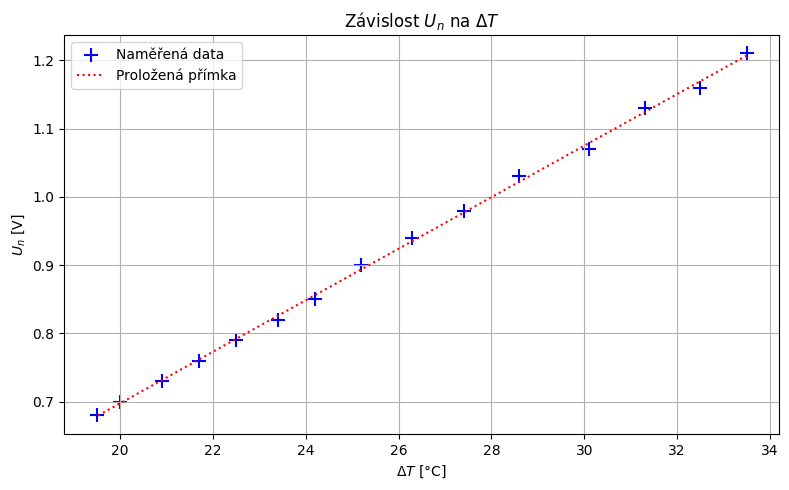

In [90]:
fit_line = np.polyval(fit_teg, teg_delta_t)

plt.figure(figsize=(8, 5))
plt.scatter(teg_delta_t, teg_un, label='Naměřená data', color='blue', marker='+', s=100)
plt.plot(teg_delta_t, fit_line, color='red', linestyle='dotted', label=f'Proložená přímka')

plt.title(r'Závislost $U_n$ na $\Delta T$')
plt.xlabel(r'$\Delta T$ [°C]')
plt.ylabel(r'$U_n$ [V]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('img/graf_peltier_zdroj.pdf')
plt.show()

### Výpočet reálné účinnosti
Máme k dispozici vzorce:

$\eta_{TEG} = \frac{P_E}{P_H}$

$P_E = \frac{1}{4} U_0 I_K$

$P_H \approx \frac{\Delta Q_H}{\Delta T} = \frac{C_{celk} (T_{H1} - T_{H_2})}{t_1 - t_2}$

---
Kde:

$\eta_{TEG}$ je účinnost Peltierova článku v režimu TEG

$P_E$ je odhad teoretického maximálního výkonu dodávaného článkem do zátěže

$P_H$ je tepelný výkon procházející teplou stranou do článku (počítáme s tím, že veškeré teplo z nádobky s horkou vodou prochází článkem)

$C_{celk} = 1121 J K^{-1}$ je celková tepelná kapacita nádobky s vodou

$T_{H1}, T_{H2}$ jsou teploty na horké straně v časech $t_1, t_2$

In [91]:
def pe(u,i):
  val = (u*i)/4
  print(f"PE = ({u}*{i})/4 = {val} W")
  return val

def ph(Th1, Th2, t1, t2):
  val = (1121*(Th1-Th2))/(t2-t1)
  print(f"PH = (1121*({Th1}-{Th2}))/({t2}-{t1}) = {val} W")
  return val

def eta_teg(pe, ph):
  return pe/ph

def eta_by_index(index):
  pe_val = pe(teg_un[index], teg_in[index])
  ph_val = ph(teg_th[index], teg_th[index+1], teg_cas[index], teg_cas[index+1])
  return(eta_teg(pe_val, ph_val))

ind = 0
eta_teg_val = eta_by_index(ind)

print("For index:", ind)
print("eta_TEG =", eta_teg_val)
print("eta_TEG =", eta_teg_val*100, "%")


PE = (1.21*0.131)/4 = 0.0396275 W
PH = (1121*(58.3-57.4))/(30-0) = 33.629999999999946 W
For index: 0
eta_TEG = 0.001178337793636636
eta_TEG = 0.1178337793636636 %


### Výpočet teoretické účinnosti vratně pracujicího tepelného stroje
$\eta'_{TEG} = \frac{T_H - T_S}{T_H}$ (pozor, dosazujeme v $K$)

Procentuálně to bude:

$p = \frac{\eta_{TEG}}{\eta'_{TEG}}$

In [92]:
def eta_theor(th, ts):
  return (th-ts)/(th+273.15)

def eta_theor_by_index(index):
  return eta_theor(teg_th[index], teg_ts[index])

eta_theor_val = eta_theor_by_index(ind)
eta_frac = eta_teg_val/eta_theor_val

print("For index:", ind)
print("eta_Theor =", eta_theor_val)
print("eta_Theor =", eta_theor_val*100, "%")
print("Poměr eta =", eta_frac*100, "%")

For index: 0
eta_Theor = 0.10107105144063962
eta_Theor = 10.107105144063961 %
Poměr eta = 1.1658509304503373 %


In [93]:
eta_over_time = []
eta_theor_over_time = []
for i in range(len(teg_cas)-1):
    eta_over_time.append(eta_by_index(i))
    eta_theor_over_time.append(eta_theor_by_index(i))

eta_over_time = np.array(eta_over_time)
eta_theor_over_time = np.array(eta_theor_over_time)

df_eta = pd.DataFrame({
    'Čas [s]': teg_cas[:-1],
    'delta T [°C]': teg_delta_t[:-1],
    'eta': eta_over_time,
    'eta_theor': eta_theor_over_time
})

display(df_eta)

PE = (1.21*0.131)/4 = 0.0396275 W
PH = (1121*(58.3-57.4))/(30-0) = 33.629999999999946 W
PE = (1.16*0.127)/4 = 0.036829999999999995 W
PH = (1121*(57.4-56.3))/(60-30) = 41.10333333333338 W
PE = (1.13*0.122)/4 = 0.034464999999999996 W
PH = (1121*(56.3-55.1))/(90-60) = 44.83999999999984 W
PE = (1.07*0.117)/4 = 0.031297500000000006 W
PH = (1121*(55.1-53.6))/(120-90) = 56.05 W
PE = (1.03*0.112)/4 = 0.02884 W
PH = (1121*(53.6-52.3))/(150-120) = 48.576666666666824 W
PE = (0.98*0.107)/4 = 0.026215 W
PH = (1121*(52.3-51.2))/(180-150) = 41.10333333333312 W
PE = (0.94*0.102)/4 = 0.023969999999999998 W
PH = (1121*(51.2-50.0))/(210-180) = 44.84000000000011 W
PE = (0.9*0.098)/4 = 0.02205 W
PH = (1121*(50.0-48.9))/(240-210) = 41.10333333333338 W
PE = (0.85*0.093)/4 = 0.0197625 W
PH = (1121*(48.9-48.0))/(270-240) = 33.629999999999946 W
PE = (0.82*0.09)/4 = 0.018449999999999998 W
PH = (1121*(48.0-47.1))/(300-270) = 33.629999999999946 W
PE = (0.79*0.086)/4 = 0.016985 W
PH = (1121*(47.1-46.2))/(330-300) =

,Čas [s],delta T [°C],eta,eta_theor
0,0,33.5,0.001178,0.101071
1,30,32.5,0.000896,0.098321
2,60,31.3,0.000769,0.095007
3,90,30.1,0.000558,0.091698
4,120,28.6,0.000594,0.087529
5,150,27.4,0.000638,0.084191
6,180,26.3,0.000535,0.081085
7,210,25.2,0.000536,0.077982
8,240,24.2,0.000588,0.075144
9,270,23.4,0.000549,0.072863


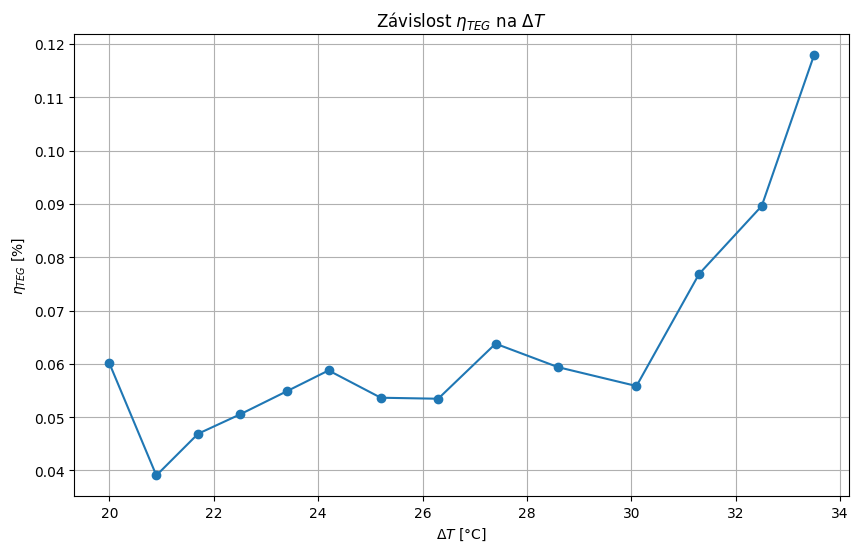

In [94]:
plt.figure(figsize=(10, 6))
plt.plot(df_eta['delta T [°C]'], df_eta['eta']*100, label='Trend účinnosti', marker='o')

plt.title(r'Závislost $\eta_{TEG}$ na $\Delta T$')
plt.xlabel(r'$\Delta T$ [°C]')
plt.ylabel(r'$\eta_{TEG}$ [%]')
plt.grid(True)
plt.savefig('img/graf_eta_delta_t.pdf')
plt.show()

## Peltier jako chladicí stroj

In [95]:
tec_cas = np.arange(0, 16)
tec_ts = np.array([26.1, 23.2, 22.2, 21.1, 20.3, 19.4, 18.7, 18.1, 17.4, 16.9, 16.3, 15.7, 15.3, 14.8, 14.4, 13.8])
tec_th = np.array([23.2, 24.5, 26.6, 26.8, 26.7, 26.8, 26.6, 26.6, 26.6, 26.5, 26.5, 26.5, 26.4, 26.3, 26.3, 26.2])

df_peltier_tec = pd.DataFrame({
    'Čas [min]': tec_cas,
    'T_s [°C]': tec_ts,
    'T_h [°C]': tec_th
})

display(df_peltier_tec)

,Čas [min],T_s [°C],T_h [°C]
0,0,26.1,23.2
1,1,23.2,24.5
2,2,22.2,26.6
3,3,21.1,26.8
4,4,20.3,26.7
5,5,19.4,26.8
6,6,18.7,26.6
7,7,18.1,26.6
8,8,17.4,26.6
9,9,16.9,26.5


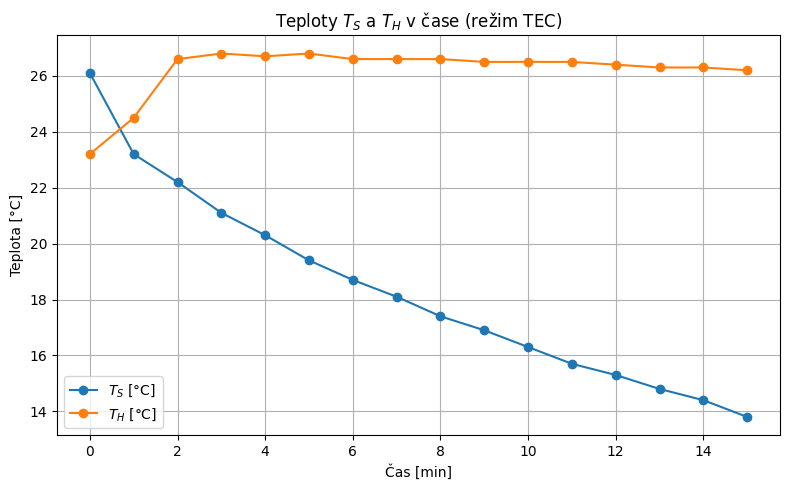

In [96]:
plt.figure(figsize=(8, 5))
plt.plot(tec_cas, tec_ts, label=r'$T_S$ [°C]', marker='o')
plt.plot(tec_cas, tec_th, label=r'$T_H$ [°C]', marker='o')

plt.title(r'Teploty $T_S$ a $T_H$ v čase (režim TEC)')
plt.xlabel(r'Čas [min]')
plt.ylabel(r'Teplota [°C]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('img/graf_peltier_chlazeni.pdf')
plt.show()

## Peltier jako ohřívač

In [97]:
teh_cas = np.arange(0, 15)
teh_ts = np.array([22.3, 19.8, 19.8, 19.8, 20.0, 20.1, 20.1, 20.3, 20.3, 20.4, 20.5, 20.6, 20.7, 20.7, 20.8])
teh_th = np.array([22.4, 28.7, 30.8, 31.8, 33.0, 33.9, 35.0, 35.7, 36.4, 37.2, 37.8, 38.6, 39.3, 39.9, 40.6])

df_peltier_teh = pd.DataFrame({
    'Čas [min]': teh_cas,
    'T_s [°C]': teh_ts,
    'T_h [°C]': teh_th
})

display(df_peltier_teh)

,Čas [min],T_s [°C],T_h [°C]
0,0,22.3,22.4
1,1,19.8,28.7
2,2,19.8,30.8
3,3,19.8,31.8
4,4,20.0,33.0
5,5,20.1,33.9
6,6,20.1,35.0
7,7,20.3,35.7
8,8,20.3,36.4
9,9,20.4,37.2


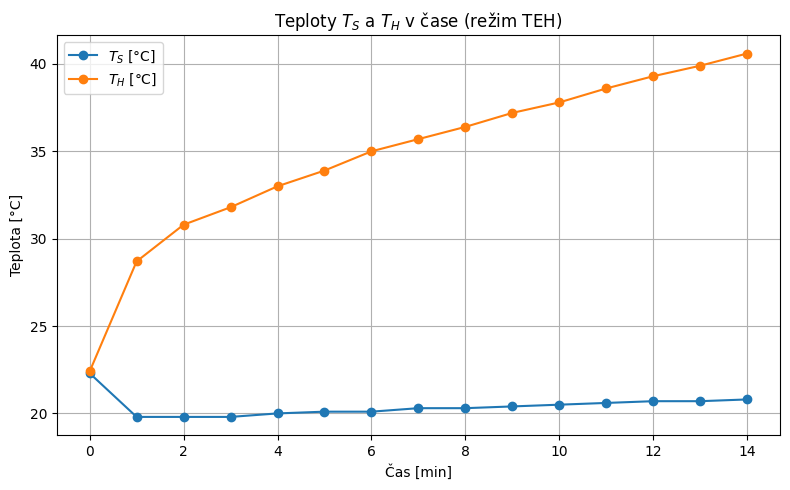

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(teh_cas, teh_ts, label=r'$T_S$ [°C]', marker='o')
plt.plot(teh_cas, teh_th, label=r'$T_H$ [°C]', marker='o')

plt.title(r'Teploty $T_S$ a $T_H$ v čase (režim TEH)')
plt.xlabel(r'Čas [min]')
plt.ylabel(r'Teplota [°C]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('img/graf_peltier_ohrev.pdf')
plt.show()

## Nejistoty

Potřebujeme zahrnout nejistotu typu B při měření napětí na článku:

$u_b(U_n) = \frac{U_n \cdot \frac{0.1}{100} + 0,003}{\sqrt{3}}$

To vypočteme pro každé naměřené napětí $U_n$ a vypočítáme průměrnou odchylku:

$u_{b(avg)} = \frac{1}{N} \sum_{i=0}^{N}{u_b(U_{ni})}$ - toto je nejistota seebeckova koeficientu

In [99]:
def ub(un):
  return((un*(0.1/100)+0.003)/np.sqrt(3))

ub_values = ub(teg_un)

df_un_ub = pd.DataFrame({
    'U_n [V]': teg_un,
    'ub(U_n) [V]': ub_values
})
display(df_un_ub)

avg_ub_values = df_un_ub['ub(U_n) [V]'].mean()
print(f"Průměrná odchylka ub_avg = {avg_ub_values*1000} mV")

ub_un = ub_values[ind]

print("ub(U_n) =", ub_un)

,U_n [V],ub(U_n) [V]
0,1.21,0.002431
1,1.16,0.002402
2,1.13,0.002384
3,1.07,0.002350
4,1.03,0.002327
5,0.98,0.002298
6,0.94,0.002275
7,0.90,0.002252
8,0.85,0.002223
9,0.82,0.002205


Průměrná odchylka ub_avg = 2.2612885543260344 mV
ub(U_n) = 0.0024306446332883246


---
Pro hodnoty proudu máme nejistotu:

$u_b(I_n) = \frac{I_n \cdot \frac{0.8}{100} + 0,003}{\sqrt{3}}$

In [100]:
def ub_current(i_n):
  return((i_n*(0.8/100)+0.003)/np.sqrt(3))

ub_in = ub_current(teg_in[ind])

print("u_b(I_n) =", ub_in)

u_b(I_n) = 0.0023371138896796056



A pro teploty máme nejistotu:

$u_b(T_n) = \frac{T_n \cdot \frac{0.05}{100} + 0,1}{\sqrt{3}}$

Tedy pro konkrétní měření:


In [101]:
def ub_temp(t):
  return ((t*0.05/100)+0.1)/np.sqrt(3)

ub_ts = ub_temp(teg_ts[ind])
ub_th = ub_temp(teg_th[ind])

ub_th1 = ub_th
ub_th2 = ub_temp(teg_th[ind+1])

print("u_b(Th1) =", ub_th1)
print("u_b(Th2) =", ub_th2)

print("u_b(Ts) =", ub_ts)
print("u_b(Th) =", ub_th)


u_b(Th1) = 0.07456478726584018
u_b(Th2) = 0.07430497964470485
u_b(Ts) = 0.06489417025691394
u_b(Th) = 0.07456478726584018


---
Dále chceme nejistotu pro účinnost, což je standardní nejistota typu C:

$u_c = \sqrt{\sum_{i=1}^{N}{a_i}} = \sqrt{\sum_{i=1}^{N}{\left(\frac{\partial \eta}{\partial x_i}\right)\cdot u_b^2(x_i)}}$

kde:
- $x_i$ je veličina na které závisí účinnost
- $u_b(x_i)$ je přístrojová nejistota měření dané veličiny. Ty máme vypočítané v předchozích krocích. Jako nejistotu pro časové údaje zvolíme cca 2 sekundy, jakožto reakční čas pozorovatele.

Vypočítáme parciální derivace a dosadíme nejistoty:

$a_1 = \left( \frac{\partial \eta}{\partial U_n} \right) \cdot u_b^2(U_n) = \frac{1}{4} \frac{I_n(t_2-t_1)}{C_{celk} (T_{H1} - T_{H_2})} \cdot u_b^2(U_n) = $

$a_2 = \left( \frac{\partial \eta}{\partial I_n} \right) \cdot u_b^2(U_n) = \frac{1}{4} \frac{U_n(t_2-t_1)}{C_{celk} (T_{H1} - T_{H_2})} \cdot u_b^2(I_n) = $

$a_3 = \left( \frac{\partial \eta}{\partial T_{H1}} \right) \cdot u_b^2(U_n) = -\frac{1}{4} \frac{U_n I_n(t_2-t_1)}{C_{celk} (T_{H1} - T_{H_2})^2} \cdot u_b^2(T_{H1}) = $

$a_4 = \left( \frac{\partial \eta}{\partial T_{H2}} \right) \cdot u_b^2(U_n) = \frac{1}{4} \frac{U_n I_n(t_2-t_1)}{C_{celk} (T_{H1} - T_{H_2})^2} \cdot u_b^2(T_{H2}) = $

$a_5 = \left( \frac{\partial \eta}{\partial t_1} \right) \cdot u_b^2(U_n) = \frac{1}{4} \frac{U_n I_n}{C_{celk} (T_{H1} - T_{H_2})} \cdot u_b^2(t_1) = $

$a_6 = \left( \frac{\partial \eta}{\partial t_2} \right) \cdot u_b^2(U_n) = \frac{1}{4} \frac{U_n I_n}{C_{celk} (T_{H1} - T_{H_2})} \cdot u_b^2(t_2) = $

In [102]:
C_celk = 1121

U_n = teg_un[ind]
I_n = teg_in[ind]
T_H1 = teg_th[ind]
T_H2 = teg_th[ind+1]
t1 = teg_cas[ind]
t2 = teg_cas[ind+1]

delta_T_ph = T_H1 - T_H2
delta_t_ph = t2 - t1

K_val = 1 / (4 * C_celk)

d_eta_d_Un = (K_val * I_n * delta_t_ph) / delta_T_ph
a1 = (d_eta_d_Un**2) * (ub_un**2)

d_eta_d_In = (K_val * U_n * delta_t_ph) / delta_T_ph
a2 = (d_eta_d_In**2) * (ub_in**2)

d_eta_d_TH1 = -(K_val * U_n * I_n * delta_t_ph) / (delta_T_ph**2)
a3 = (d_eta_d_TH1**2) * (ub_th1**2)

d_eta_d_TH2 = (K_val * U_n * I_n * delta_t_ph) / (delta_T_ph**2)
a4 = (d_eta_d_TH2**2) * (ub_th2**2)

d_eta_d_t1 = -(K_val * U_n * I_n) / delta_T_ph
a5 = (d_eta_d_t1**2) * (2**2)

d_eta_d_t2 = (K_val * U_n * I_n) / delta_T_ph
a6 = (d_eta_d_t2**2) * (2**2)

u_c_eta = np.sqrt(a1 + a2 + a3 + a4 + a5 + a6)

print("uc_eta =", u_c_eta)
print("uc_eta =", u_c_eta*100, "%")

uc_eta = 0.00017828226108904823
uc_eta = 0.017828226108904822 %


---
Nejistota pro účinnost vratně pracujícího tepelného stroje:

Použijeme vzorec pro nejistotu typu C výše, kde dosadíme následující parciální derivace:

$\frac{\partial \eta'}{T_H} = \frac{T_S}{T_H^2}$

$\frac{\partial \eta'}{T_S} = -\frac{1}{T_H}$



In [103]:
ts = teg_ts[ind]
th = teg_th[ind]

b1 = ((ts/th**2)**2) * (ub_th**2)
b2 = ((-1/th)**2) * (ub_ts**2)

uc_eta_theor = np.sqrt(b1 + b2)

print("uc_eta_theoretical =", uc_eta_theor)
print("uc_eta_theoretical =", uc_eta_theor*100, "%")

uc_eta_theoretical = 0.0012389559426232032
uc_eta_theoretical = 0.12389559426232032 %
